# Figure 2: Ablation Study — Panel Label Fix

Remove periods from panel labels: "A." → "A", "B." → "B"

**Instructions:** Upload `training_histories.json` from `figures/data/` when prompted.

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

# Upload training_histories.json
uploaded = files.upload()

Saving training_histories.json to training_histories.json


In [2]:
with open('training_histories.json', 'r') as f:
    histories = json.load(f)

stage1_5 = histories['stage1_5']
stage2 = histories['stage2']

print(f"Stage 1.5: {len(stage1_5['epochs'])} epochs, final val_r = {stage1_5['val_r'][-1]:.4f}")
print(f"Stage 2: {len(stage2['epochs'])} epochs, final val_r = {stage2['val_r'][-1]:.4f}")

Stage 1.5: 379 epochs, final val_r = 0.6368
Stage 2: 32 epochs, final val_r = 0.3391


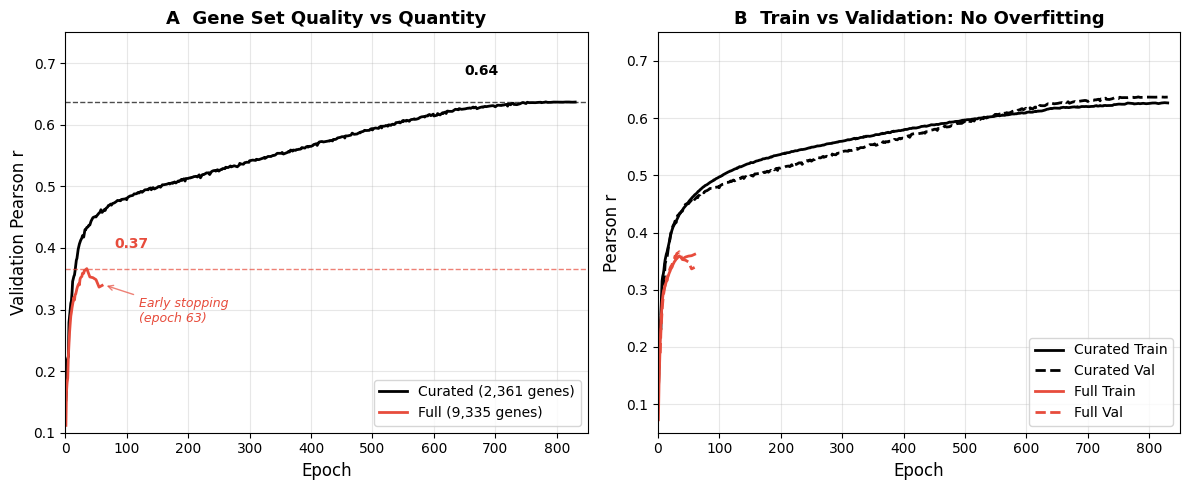

Saved: fig2_ablation_study.png and .pdf


In [3]:
# Colors
COLOR_CURATED = '#000000'  # Black
COLOR_FULL = '#E74C3C'     # Red

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# === Panel A: Gene Set Quality vs Quantity ===
ax1 = axes[0]
ax1.plot(stage1_5['epochs'], stage1_5['val_r'], color=COLOR_CURATED, linewidth=2,
         label='Curated (2,361 genes)')
ax1.plot(stage2['epochs'], stage2['val_r'], color=COLOR_FULL, linewidth=2,
         label='Full (9,335 genes)')

# Horizontal dashed lines
ax1.axhline(y=0.6371, color=COLOR_CURATED, linestyle='--', alpha=0.7, linewidth=1)
ax1.axhline(y=0.3664, color=COLOR_FULL, linestyle='--', alpha=0.7, linewidth=1)

# Annotate best values
ax1.annotate('0.64', xy=(782, 0.6371), xytext=(650, 0.68),
             fontsize=10, color=COLOR_CURATED, fontweight='bold')
ax1.annotate('0.37', xy=(35, 0.3664), xytext=(80, 0.40),
             fontsize=10, color=COLOR_FULL, fontweight='bold')

# Early stopping
ax1.annotate('Early stopping\n(epoch 63)', xy=(63, 0.34), xytext=(120, 0.28),
             fontsize=9, color=COLOR_FULL, fontstyle='italic',
             arrowprops=dict(arrowstyle='->', color=COLOR_FULL, alpha=0.7))

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Validation Pearson r', fontsize=12)
ax1.set_title('A  Gene Set Quality vs Quantity', fontsize=13, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.set_xlim(0, 850)
ax1.set_ylim(0.1, 0.75)
ax1.grid(True, alpha=0.3)

# === Panel B: Train vs Validation ===
ax2 = axes[1]
ax2.plot(stage1_5['epochs'], stage1_5['train_r'], color=COLOR_CURATED, linestyle='-', linewidth=2,
         label='Curated Train')
ax2.plot(stage1_5['epochs'], stage1_5['val_r'], color=COLOR_CURATED, linestyle='--', linewidth=2,
         label='Curated Val')
ax2.plot(stage2['epochs'], stage2['train_r'], color=COLOR_FULL, linestyle='-', linewidth=2,
         label='Full Train')
ax2.plot(stage2['epochs'], stage2['val_r'], color=COLOR_FULL, linestyle='--', linewidth=2,
         label='Full Val')

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Pearson r', fontsize=12)
ax2.set_title('B  Train vs Validation: No Overfitting', fontsize=13, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10)
ax2.set_xlim(0, 850)
ax2.set_ylim(0.05, 0.75)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_ablation_study.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('fig2_ablation_study.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: fig2_ablation_study.png and .pdf')

In [4]:
# Download
files.download('fig2_ablation_study.png')
files.download('fig2_ablation_study.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>